# Create delta-DG1 model

**Goal:**

Create a model for the DG1 model that uses a delta subinterval plus the CG1 interval for the bottom branch.

**Procedure:**
1. Create a new `create_model` function for the delta model.
2. Save the updated config for the new delta model.
3. Decide on alpha, term: Proportion of the cell cycle length similar to Xin's alpha value. (What is the literature on the estimated length of G1?)
4. Create a new calcH function to create the new delta H model.
    - (Will calcH just work with the new intervals?)
5. Plot the model diagram (validation)
6. Plot the growth diagram (validation)


In [11]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [74]:
from src.create_models_delta import create_wt1_model

alpha = 16
modelfile1 = create_wt1_model(f'models/yl_cell_cycle/wt1_rg1_delta.{alpha}.label', alpha)


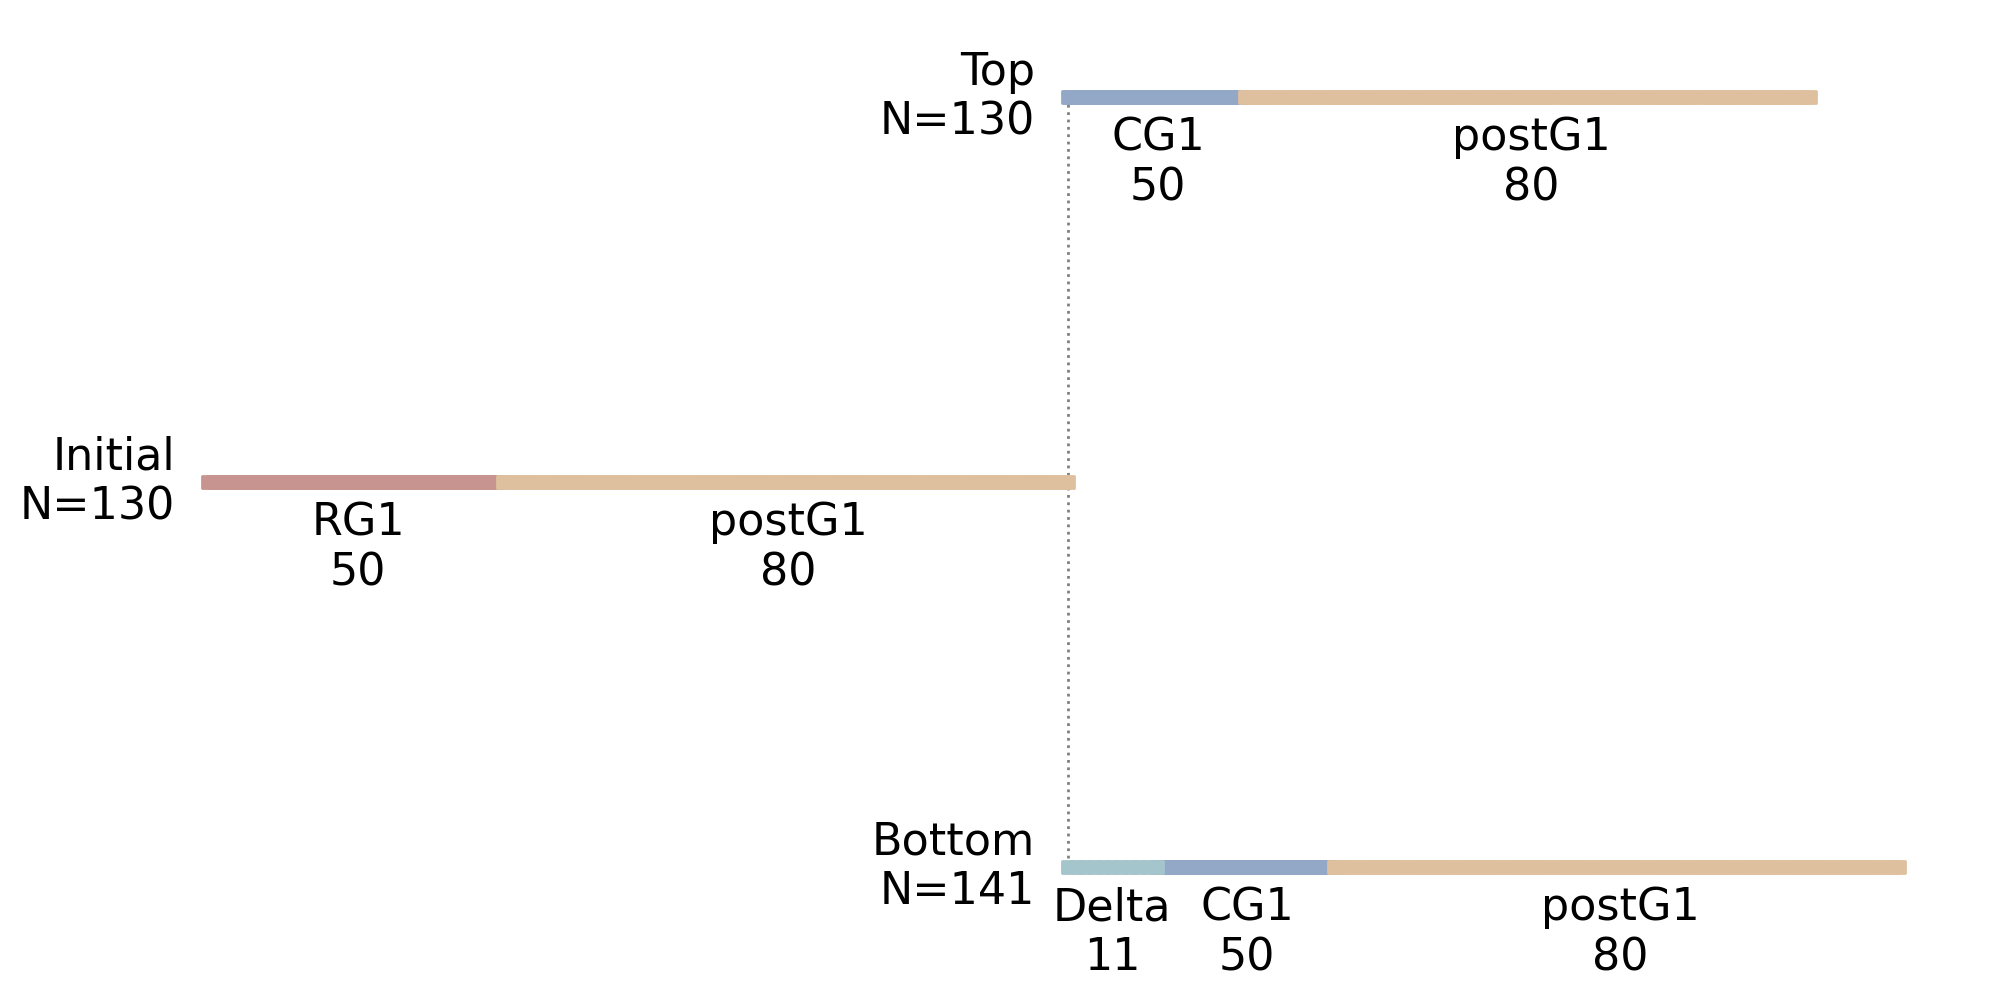

In [75]:
from src.ModelFile import ModelFile

model_file_loaded = ModelFile()
model_file_loaded.load_model(modelfile1)

model_file_loaded.plot_model()


In [79]:
# Create the H for the updated model config to include the H config
from src.delta_config import load_yl_delta_config

config = load_yl_delta_config(1)


In [82]:
from src.helpers import calcH

H, Hpositions = calcH(config.intervals_wt1, config.WT1_TIMEPOINTS)


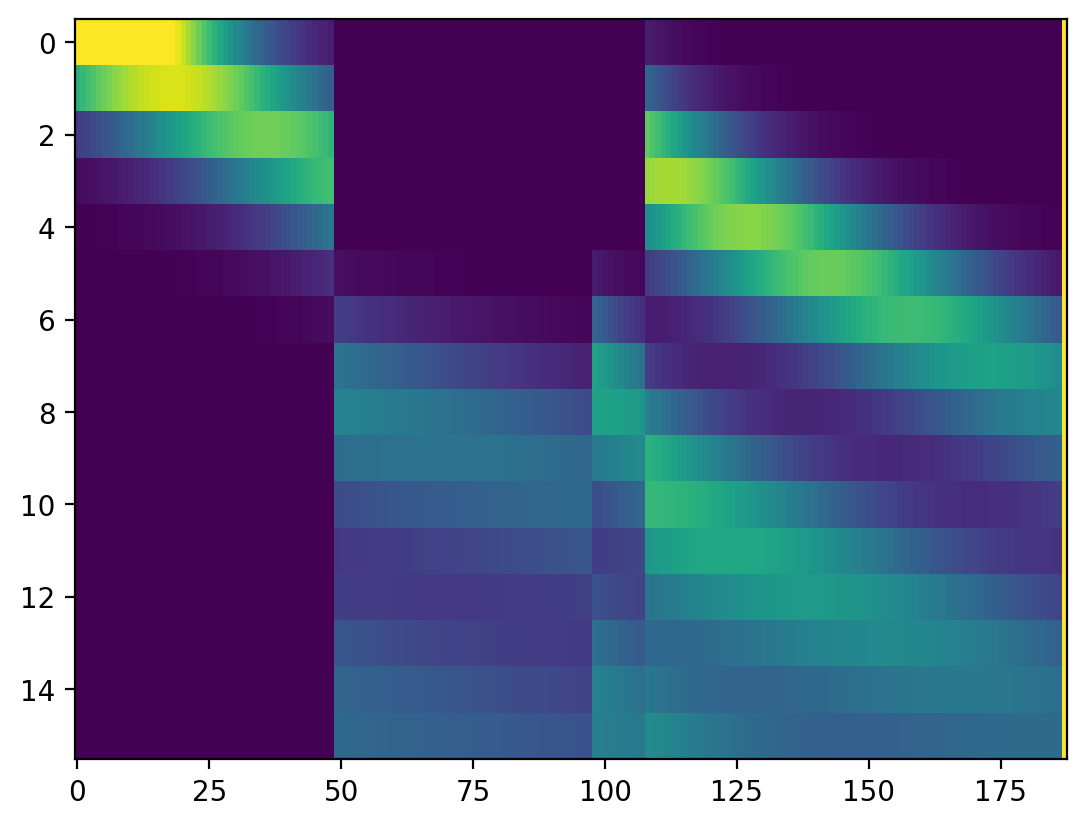

In [89]:
plt.imshow(H, vmax=0.02, aspect='auto')

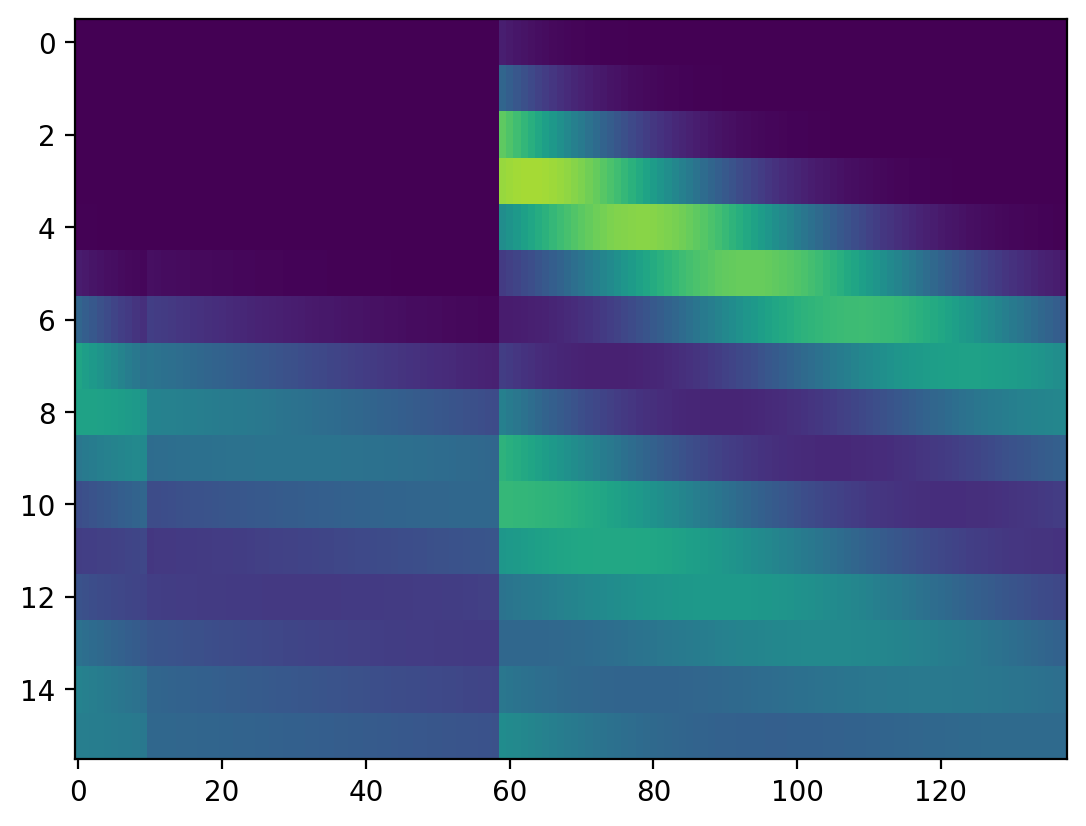

In [149]:

# Checking the DG1 is a smooth transition from the "Delta" phase 
# into CG1
bottom_indices = config.get_Hpositions_for_branch('b')
bottom_H = H[:, bottom_indices]
plt.imshow(bottom_H, vmax=0.02, aspect='auto')


In [167]:
from src.config import plot_H

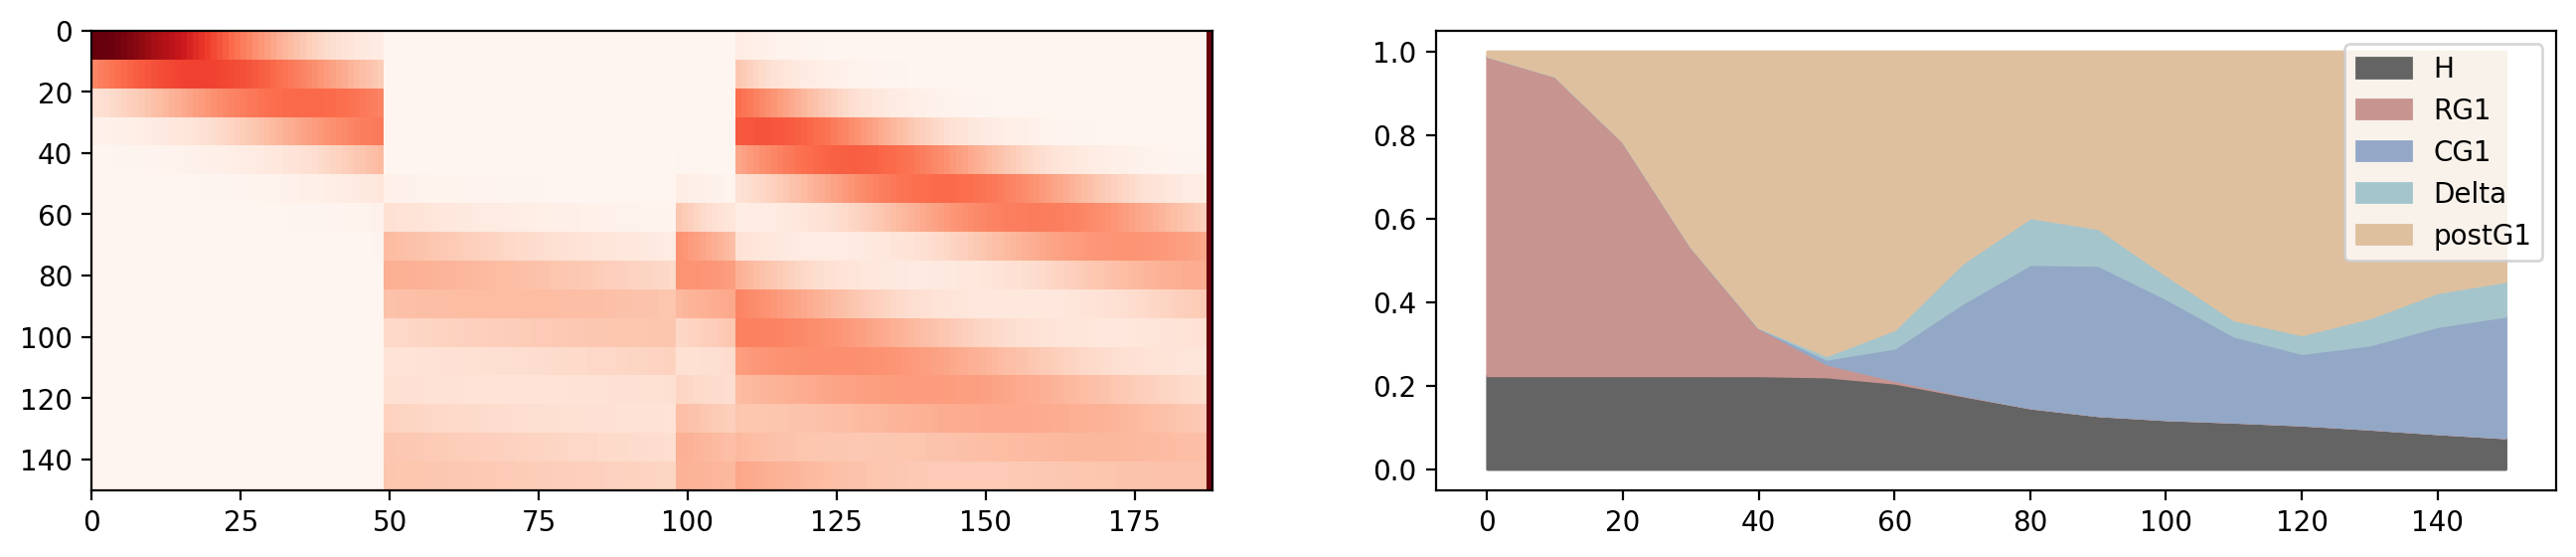

In [169]:
plot_H(config, H)